In [166]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [167]:
import pandas
data = pandas.read_csv("churn.csv")

data = data.drop(columns = [ 'customerID' ])
data = data[data["TotalCharges"] != ' ']
data["TotalCharges"] = data["TotalCharges"].astype(float)

data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [168]:
cols_to_replace = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']  # названия нужных колонок
data[cols_to_replace] = data[cols_to_replace].replace(['No phone service', 'No internet service'], 'No')

In [169]:
data = data.drop(columns = cols_to_replace)

In [170]:
for column in data.columns:
    print(column, numpy.unique(data[column]))

gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['No' 'Yes']
Dependents ['No' 'Yes']
tenure [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
PhoneService ['No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['No' 'Yes']
PaymentMethod ['Bank transfer (automatic)' 'Credit card (automatic)' 'Electronic check'
 'Mailed check']
MonthlyCharges [ 18.25  18.4   18.55 ... 118.6  118.65 118.75]
TotalCharges [  18.8    18.85   18.9  ... 8670.1  8672.45 8684.8 ]
Churn ['No' 'Yes']


In [171]:
import sklearn.model_selection

X = data.drop(columns = [ "Churn" ])
y = (data["Churn"] == "Yes").to_numpy()

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size = 0.1, stratify = y, random_state = 1
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6328, 12), (704, 12), (6328,), (704,))

In [172]:
numeric = [ "tenure", "MonthlyCharges", "TotalCharges" ]
categorical = list(set(X_train.columns) - set(numeric))

len(numeric), len(categorical), len(X_train.columns)

(3, 9, 12)

In [173]:
import sklearn.compose
import sklearn.preprocessing

ct = sklearn.compose.ColumnTransformer(
    transformers=[
        ("numeric", 'passthrough', numeric),
        ("categorical", sklearn.preprocessing.OneHotEncoder(), categorical)
    ]
)
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

X_train.shape, X_test.shape

((6328, 25), (704, 25))

In [174]:
y_train.shape, y_test.shape

((6328,), (704,))

In [175]:
import sklearn.preprocessing

ss = sklearn.preprocessing.StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

In [152]:
import tqdm
from utils import estimate_quality

import xgboost
import catboost
import sklearn.svm
import sklearn.tree
import sklearn.ensemble
import sklearn.neighbors
import sklearn.naive_bayes
import sklearn.linear_model
import sklearn.neural_network

models = [
    # neighbors
    sklearn.neighbors.KNeighborsClassifier(n_jobs = -1, n_neighbors = 50),
    sklearn.neighbors.RadiusNeighborsClassifier(n_jobs = -1, radius = 7),

    # naive_bayes
    sklearn.naive_bayes.BernoulliNB(),
    sklearn.naive_bayes.GaussianNB(),

    # linear_model
    sklearn.linear_model.LogisticRegression(),
    
    # svm
    sklearn.svm.SVC(probability = True),
    sklearn.svm.NuSVC(probability = True),
    
    # tree
    sklearn.tree.DecisionTreeClassifier(),
    sklearn.tree.ExtraTreeClassifier(),

    # ensemble
    sklearn.ensemble.BaggingClassifier(n_estimators = 100, random_state = 42, n_jobs = -1),
    sklearn.ensemble.AdaBoostClassifier(n_estimators = 500, algorithm = 'SAMME', random_state = 42),
    sklearn.ensemble.ExtraTreesClassifier(n_estimators = 500, random_state = 42, n_jobs = -1),
    sklearn.ensemble.RandomForestClassifier(n_estimators = 1000, random_state = 42, n_jobs = -1),
    sklearn.ensemble.GradientBoostingClassifier(n_estimators = 1000, random_state = 42),
    sklearn.ensemble.HistGradientBoostingClassifier(random_state = 42),

    # neural_network
    sklearn.neural_network.MLPClassifier(max_iter = 2000),
    
    # xgboost
    xgboost.XGBClassifier(n_jobs = -1, n_estimators = 50, max_depth = 4, device = 'gpu'),

    # catboost
    catboost.CatBoostClassifier(
        iterations = 600,
        depth = 4,
        random_seed = 42,
        loss_function = 'MultiClass',
        devices = '0-3',
        task_type = 'CPU',
        verbose = False
    ),
]

results = []
for model in tqdm.tqdm(models):
    model.fit(X_train_scaled, y_train)
    metrics = estimate_quality(model.predict_proba(X_test_scaled), y_test)
    results.append({ 'model': str(model), **metrics })
pandas.DataFrame(results)

 94%|█████████▍| 17/18 [00:36<00:02,  2.83s/it]

[19:32:37] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-10.9-x86_64-cpython-37/xgboost/src/learner.cc:627: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




100%|██████████| 18/18 [00:38<00:00,  2.15s/it]


,model,Accuracy,Precision,Recall,AUC-ROC,F1-score,True Positive,True Negative,False Positive,False Negative,True Negative Rate (Specificity),Negative Predictive Value,False Positive Rate,False Discovery Rate
0,"KNeighborsClassifier(n_jobs=-1, n_neighbors=50)",0.802557,0.641176,0.582888,0.800851,0.610644,109,456,61,78,0.882012,0.853933,0.117988,0.358824
1,"RadiusNeighborsClassifier(n_jobs=-1, radius=7)",0.734375,0.000000,0.000000,0.802361,0.000000,0,517,0,187,1.000000,0.734375,0.000000,0.000000
2,BernoulliNB(),0.707386,0.468013,0.743316,0.802387,0.574380,139,359,158,48,0.694391,0.882064,0.305609,0.531987
3,GaussianNB(),0.640625,0.412234,0.828877,0.809659,0.550622,155,296,221,32,0.572534,0.902439,0.427466,0.587766
4,LogisticRegression(),0.798295,0.645161,0.534759,0.822857,0.584795,100,462,55,87,0.893617,0.841530,0.106383,0.354839
5,SVC(probability=True),0.801136,0.671533,0.491979,0.769464,0.567901,92,472,45,95,0.912959,0.832451,0.087041,0.328467
6,NuSVC(probability=True),0.802557,0.690476,0.465241,0.784648,0.555911,87,478,39,100,0.924565,0.826990,0.075435,0.309524
7,DecisionTreeClassifier(),0.732955,0.497512,0.534759,0.668801,0.515464,100,416,101,87,0.804642,0.827038,0.195358,0.502488
8,ExtraTreeClassifier(),0.741477,0.512953,0.529412,0.672887,0.521053,99,423,94,88,0.818182,0.827789,0.181818,0.487047
9,"BaggingClassifier(n_estimators=100, n_jobs=-1,...",0.781250,0.605096,0.508021,0.793926,0.552326,95,455,62,92,0.880077,0.831810,0.119923,0.394904


In [176]:
pandas.DataFrame(X_test.copy(), columns = ct.get_feature_names_out())

,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__InternetService_DSL,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__PaperlessBilling_No,categorical__PaperlessBilling_Yes,categorical__Contract_Month-to-month,categorical__Contract_One year,...,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,categorical__gender_Female,categorical__gender_Male,categorical__Dependents_No,categorical__Dependents_Yes,categorical__PhoneService_No,categorical__PhoneService_Yes
0,1.0,20.05,20.05,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
1,62.0,90.70,5586.45,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
2,64.0,47.85,3147.50,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,1.0,20.35,20.35,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
4,65.0,79.40,5071.90,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,46.0,20.25,890.35,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
700,1.0,69.35,69.35,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
701,50.0,94.40,4914.90,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
702,51.0,94.00,4905.75,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0


In [177]:
import numpy

X_train_df = pandas.DataFrame(X_train.copy(), columns = ct.get_feature_names_out())
X_test_df = pandas.DataFrame(X_test.copy(), columns = ct.get_feature_names_out())

for column in X_train_df.columns:
    if len(numpy.unique(X_train_df[column])) == 2:
        X_train_df[column] = X_train_df[column].astype(bool)
        X_test_df[column] = X_test_df[column].astype(bool)

X_train_df

,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__InternetService_DSL,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__PaperlessBilling_No,categorical__PaperlessBilling_Yes,categorical__Contract_Month-to-month,categorical__Contract_One year,...,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,categorical__gender_Female,categorical__gender_Male,categorical__Dependents_No,categorical__Dependents_Yes,categorical__PhoneService_No,categorical__PhoneService_Yes
0,35.0,85.30,2917.50,False,True,False,True,False,True,False,...,False,True,False,False,True,False,True,False,False,True
1,3.0,35.15,99.75,True,False,False,False,True,True,False,...,False,False,True,False,False,True,True,False,True,False
2,6.0,89.50,573.30,False,True,False,False,True,True,False,...,False,False,True,False,True,False,True,False,False,True
3,72.0,94.25,6849.75,False,True,False,False,True,False,False,...,True,False,False,False,True,False,True,False,False,True
4,72.0,114.65,8333.95,False,True,False,False,True,False,False,...,True,False,False,False,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6323,1.0,20.20,20.20,False,False,True,True,False,True,False,...,False,False,False,True,False,True,True,False,False,True
6324,69.0,114.35,7665.80,False,True,False,False,True,False,False,...,True,False,False,False,False,True,False,True,False,True
6325,59.0,50.25,2997.45,True,False,False,False,True,True,False,...,False,False,True,False,False,True,True,False,True,False
6326,4.0,19.60,93.45,False,False,True,True,False,True,False,...,False,False,False,True,True,False,True,False,False,True


In [178]:
X_test_df

,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__InternetService_DSL,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__PaperlessBilling_No,categorical__PaperlessBilling_Yes,categorical__Contract_Month-to-month,categorical__Contract_One year,...,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,categorical__gender_Female,categorical__gender_Male,categorical__Dependents_No,categorical__Dependents_Yes,categorical__PhoneService_No,categorical__PhoneService_Yes
0,1.0,20.05,20.05,False,False,True,True,False,True,False,...,False,False,False,True,False,True,True,False,False,True
1,62.0,90.70,5586.45,False,True,False,True,False,True,False,...,True,False,False,False,False,True,True,False,False,True
2,64.0,47.85,3147.50,True,False,False,True,False,False,False,...,False,False,True,False,True,False,True,False,True,False
3,1.0,20.35,20.35,False,False,True,True,False,True,False,...,False,False,False,True,False,True,True,False,False,True
4,65.0,79.40,5071.90,True,False,False,False,True,False,False,...,True,False,False,False,True,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,46.0,20.25,890.35,False,False,True,True,False,False,False,...,True,False,False,False,True,False,False,True,False,True
700,1.0,69.35,69.35,False,True,False,False,True,True,False,...,False,False,True,False,False,True,True,False,False,True
701,50.0,94.40,4914.90,False,True,False,False,True,True,False,...,False,True,False,False,False,True,True,False,False,True
702,51.0,94.00,4905.75,False,True,False,False,True,False,True,...,True,False,False,False,False,True,True,False,False,True


In [279]:
import tqdm
import typing
import joblib

class LazyClassifierFCA:
    def fit(self, X_train: pandas.DataFrame, y_train: pandas.Series) -> None:
        self.bool_columns = list(X_train.columns[X_train.dtypes == 'bool'])
        self.numeric_columns = list(X_train.columns[X_train.dtypes != 'bool'])

        self.binary_X_train_positive = X_train[y_train == 1][self.bool_columns].to_numpy().astype(bool)
        self.numerical_X_train_positive = X_train[y_train == 1][self.numeric_columns].to_numpy()
        self.binary_X_train_negative = X_train[y_train == 0][self.bool_columns].to_numpy().astype(bool)
        self.numerical_X_train_negative = X_train[y_train == 0][self.numeric_columns].to_numpy()

        self.cache = {}

    def cached_matches(self, binary_intersection, numeric_intersection_minimums, numeric_intersection_maximums):
        key = tuple([*binary_intersection, *numeric_intersection_minimums, *numeric_intersection_maximums])
        self.cache[key] = 1
        return

        for a, b, c in self.cache:
            if (a == binary_intersection).all() and (b == numeric_intersection_minimums).all() and (c == numeric_intersection_maximums).all():
                print('!!!!!!!!!!!!')
        self.cache.append((binary_intersection, numeric_intersection_minimums, numeric_intersection_maximums))

        
    def classify_sample(self, sample: pandas.Series) -> typing.Any:
        sample_bin = sample[self.bool_columns].to_numpy().astype(bool)
        sample_num = sample[self.numeric_columns].to_numpy()

        def find_matches(bin, num):
            binary_intersection = sample_bin & bin

            numeric_intersection_minimums = numpy.vstack([ sample_num, num ]).min(axis = 0)
            numeric_intersection_maximums = numpy.vstack([ sample_num, num ]).max(axis = 0)

            # if binary_intersection.sum() > 15:
            #     return 0, 0, (binary_intersection, numeric_intersection_minimums, numeric_intersection_maximums)

            # key = tuple([*binary_intersection, *numeric_intersection_minimums, *numeric_intersection_maximums])
            # if key in self.cache:
            #     return self.cache[key]

            binary_positive_match = (self.binary_X_train_positive | ~binary_intersection).all(axis = 1)
            binary_negative_match = (self.binary_X_train_negative | ~binary_intersection).all(axis = 1)
            
            numerical_positive_minimum = (numeric_intersection_minimums <= self.numerical_X_train_positive)
            numerical_positive_maximum = (self.numerical_X_train_positive <= numeric_intersection_maximums)
            numerical_positive_match = (numerical_positive_minimum & numerical_positive_maximum).all(axis = 1)

            numerical_negative_minimum = (numeric_intersection_minimums <= self.numerical_X_train_negative)
            numerical_negative_maximum = (self.numerical_X_train_negative <= numeric_intersection_maximums)
            numerical_negative_match = (numerical_negative_minimum & numerical_negative_maximum).all(axis = 1)

            num_positive = (binary_positive_match & numerical_positive_match).sum()
            num_negative = (binary_negative_match & numerical_negative_match).sum()
            # self.cache[key] = (num_positive, num_negative)
            # print(binary_intersection, numeric_intersection_minimums, numeric_intersection_maximums, num_positive, num_negative)
            return num_positive, num_negative, (binary_intersection, numeric_intersection_minimums, numeric_intersection_maximums)

        positive_classifiers = 0
        negative_classifiers = 0

        positive = {}
        for pos_bin, pos_num in zip(self.binary_X_train_positive, self.numerical_X_train_positive):
            num_positive, num_negative, hypothesis = find_matches(pos_bin, pos_num)
            if 5 * num_positive > num_negative:
                positive_classifiers += 1
                key = tuple([*map(bool, hypothesis[0]), *map(float, hypothesis[1]), *map(float, hypothesis[2])])
                if key not in positive:
                    positive[key] = 0
                positive[key] += 1

        negative = {}
        for neg_bin, neg_num in zip(self.binary_X_train_negative, self.numerical_X_train_negative):
            num_positive, num_negative, hypothesis = find_matches(neg_bin, neg_num)
            if num_negative > 5 * num_positive:
                negative_classifiers += 1
                key = tuple([*map(bool, hypothesis[0]), *map(float, hypothesis[1]), *map(float, hypothesis[2])])
                if key not in negative:
                    negative[key] = 0
                negative[key] += 1

        # print('Positive: ', positive)
        # print('Negative: ', negative)
        # print('Positive: ', positive_classifiers)
        # print('Negative: ', negative_classifiers)
        total = negative_classifiers + positive_classifiers
        return [ (negative_classifiers / total), (positive_classifiers / total) ], positive, negative


    def predict(self, X_test: pandas.DataFrame) -> typing.List[typing.Any]:
        def do(sample):
            return self.classify_sample(sample)
        return joblib.Parallel(n_jobs = -1)(
            joblib.delayed(do)(sample)
            for _, sample in tqdm.tqdm(X_test.iterrows(), total = len(X_test))
        )

    # --- Interpretability helpers ---
    def _pretty_feature_name(self, col: str) -> str:
        """Make encoded feature names (from ColumnTransformer / OneHotEncoder) more readable."""
        if "__" in col:
            col = col.split("__", 1)[1]
        return col.replace("_", " ")

    def _decode_hypothesis_key(self, key: tuple) -> typing.Dict[str, typing.List[str]]:
        """Decode a hypothesis key into human-readable boolean and numeric conditions."""
        B = len(self.bool_columns)
        N = len(self.numeric_columns)

        bool_part = key[:B]
        mins = key[B:B + N]
        maxs = key[B + N:]

        bool_conditions = [
            self._pretty_feature_name(self.bool_columns[i])
            for i, v in enumerate(bool_part)
            if v
        ]

        numeric_conditions = []
        for j, col in enumerate(self.numeric_columns):
            lo = mins[j]
            hi = maxs[j]
            name = self._pretty_feature_name(col)
            if lo == hi:
                numeric_conditions.append(f"{name} == {lo}")
            else:
                numeric_conditions.append(f"{name} in [{lo}, {hi}]")

        return {
            "bool_conditions": bool_conditions,
            "numeric_conditions": numeric_conditions,
        }

    def _summarize_hypotheses(self, hypotheses: typing.Dict[tuple, int], top_k: int = 5) -> typing.List[typing.Dict[str, typing.Any]]:
        """Take a dict of hypotheses -> count and return top_k decoded ones."""
        if not hypotheses:
            return []

        sorted_hyps = sorted(hypotheses.items(), key=lambda kv: kv[1], reverse=True)[:top_k]
        summary = []
        for key, weight in sorted_hyps:
            decoded = self._decode_hypothesis_key(key)
            summary.append({
                "weight": int(weight),
                **decoded,
            })
        return summary

    def explain_sample(self, sample: pandas.Series, top_k: int = 5, verbose: bool = True) -> typing.Dict[str, typing.Any]:
        """Run classification and return a human-readable explanation for this sample.

        Returns a dict with:
        - predicted_label (0/1)
        - probabilities (negative / positive)
        - num_positive_hypotheses / num_negative_hypotheses
        - top_positive_hypotheses / top_negative_hypotheses (decoded conditions)
        """
        proba, pos_hyps, neg_hyps = self.classify_sample(sample)
        predicted_label = int(proba[1] >= proba[0])

        explanation = {
            "predicted_label": predicted_label,
            "probabilities": {
                "negative": float(proba[0]),
                "positive": float(proba[1]),
            },
            "num_positive_hypotheses": int(len(pos_hyps)),
            "num_negative_hypotheses": int(len(neg_hyps)),
            "top_positive_hypotheses": self._summarize_hypotheses(pos_hyps, top_k),
            "top_negative_hypotheses": self._summarize_hypotheses(neg_hyps, top_k),
        }

        if verbose:
            print(f"Predicted label: {predicted_label} (0 = negative, 1 = positive)")
            print(
                "Probabilities: "
                f"negative={explanation['probabilities']['negative']:.3f}, "
                f"positive={explanation['probabilities']['positive']:.3f}"
            )
            print(
                f"Number of positive hypotheses: {explanation['num_positive_hypotheses']}\n"
                f"Number of negative hypotheses: {explanation['num_negative_hypotheses']}"
            )

            print("\nTop positive hypotheses:")
            for h in explanation["top_positive_hypotheses"]:
                print(f"  weight = {h['weight']}")
                if h["bool_conditions"]:
                    print("    boolean conditions: " + ", ".join(h["bool_conditions"]))
                if h["numeric_conditions"]:
                    print("    numeric conditions: " + ", ".join(h["numeric_conditions"]))

            print("\nTop negative hypotheses:")
            for h in explanation["top_negative_hypotheses"]:
                print(f"  weight = {h['weight']}")
                if h["bool_conditions"]:
                    print("    boolean conditions: " + ", ".join(h["bool_conditions"]))
                if h["numeric_conditions"]:
                    print("    numeric conditions: " + ", ".join(h["numeric_conditions"]))

        return explanation


In [265]:
fca = LazyClassifierFCA()
fca.fit(X_train_df, y_train)
_, pos, neg = fca.classify_sample(X_test_df.iloc[0])

Positive:  {(False, False, False, True, False, True, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, True, 1.0, 20.05, 20.05, 35.0, 85.3, 2917.5): 1, (False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, True, True, False, False, False, 1.0, 20.05, 20.05, 3.0, 35.15, 99.75): 1, (False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, True, 1.0, 20.05, 20.05, 6.0, 89.5, 573.3): 1, (False, False, False, True, False, True, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, True, 1.0, 20.05, 20.05, 13.0, 89.4, 1132.35): 1, (False, False, False, False, False, True, False, False, False, True, True, False, False, False, False, False, False, True, True, False, False, True, 1.0, 20.05, 20.05, 21.0, 96.8, 2030.3): 1, (False, False, False, F

In [266]:
y_train[0]

np.True_

In [267]:
res_pos = {}
for i, feature in enumerate(fca.bool_columns):
    res_pos[feature] = 0
    for cls in pos:
        if cls[i]:
            res_pos[feature] += 1

res_neg = {}
for i, feature in enumerate(fca.bool_columns):
    res_neg[feature] = 0
    for cls in neg:
        if cls[i]:
            res_neg[feature] += 1

In [269]:
len(pos), len(neg)

(1648, 1040)

In [270]:
res_pos

{'categorical__InternetService_DSL': 0,
 'categorical__InternetService_Fiber optic': 0,
 'categorical__InternetService_No': 77,
 'categorical__PaperlessBilling_No': 404,
 'categorical__PaperlessBilling_Yes': 0,
 'categorical__Contract_Month-to-month': 1473,
 'categorical__Contract_One year': 0,
 'categorical__Contract_Two year': 0,
 'categorical__SeniorCitizen_0': 0,
 'categorical__SeniorCitizen_1': 426,
 'categorical__Partner_No': 1062,
 'categorical__Partner_Yes': 0,
 'categorical__PaymentMethod_Bank transfer (automatic)': 0,
 'categorical__PaymentMethod_Credit card (automatic)': 0,
 'categorical__PaymentMethod_Electronic check': 0,
 'categorical__PaymentMethod_Mailed check': 262,
 'categorical__gender_Female': 0,
 'categorical__gender_Male': 807,
 'categorical__Dependents_No': 1360,
 'categorical__Dependents_Yes': 0,
 'categorical__PhoneService_No': 0,
 'categorical__PhoneService_Yes': 1494}

In [271]:
res_neg

{'categorical__InternetService_DSL': 0,
 'categorical__InternetService_Fiber optic': 0,
 'categorical__InternetService_No': 851,
 'categorical__PaperlessBilling_No': 793,
 'categorical__PaperlessBilling_Yes': 0,
 'categorical__Contract_Month-to-month': 150,
 'categorical__Contract_One year': 0,
 'categorical__Contract_Two year': 0,
 'categorical__SeniorCitizen_0': 0,
 'categorical__SeniorCitizen_1': 45,
 'categorical__Partner_No': 363,
 'categorical__Partner_Yes': 0,
 'categorical__PaymentMethod_Bank transfer (automatic)': 0,
 'categorical__PaymentMethod_Credit card (automatic)': 0,
 'categorical__PaymentMethod_Electronic check': 0,
 'categorical__PaymentMethod_Mailed check': 418,
 'categorical__gender_Female': 0,
 'categorical__gender_Male': 529,
 'categorical__Dependents_No': 473,
 'categorical__Dependents_Yes': 0,
 'categorical__PhoneService_No': 0,
 'categorical__PhoneService_Yes': 971}

In [273]:
y_train[0]

np.True_

In [274]:
len(pos), len(neg)

(1648, 1040)

In [263]:
y_train[0]

np.True_

In [243]:
def subsumes(hyp1, hyp2):
    for i in range(len(fca.bool_columns)):
        if hyp1[i] and not hyp2[i]:
            return False
        
    num_bool = len(fca.bool_columns)
    for i in range(len(fca.numeric_columns)):
        if hyp1[num_bool + i] > hyp2[num_bool + i]:
            return False
        
    for i in range(len(fca.numeric_columns)):
        if hyp1[num_bool + 3 + i] < hyp2[num_bool + 3 + i]:
            return False
    
    return True

subsumes(a, a)

True

In [277]:
mmm = {}
    
cou = 0
tt = []
for key in pos:
    can_remove = False
    for key2 in pos:
        if key != key2 and subsumes(key, key2):
            can_remove = True
            break
    if not can_remove:
        result = list()
        num_bool = len(fca.bool_columns)
        for i in range(len(fca.bool_columns)):
            if key[i]:
                result.append(fca.bool_columns[i])
            else:
                result.append(' ')
        for j in range(len(fca.numeric_columns)):
            result.append(f"{fca.numeric_columns[j]} [{key[num_bool + j]}; {key[num_bool + 3 + j]}]")
        tt.append(result)
        cou += 1

pandas.DataFrame(tt).to_csv("pos.csv")

In [278]:
mmm = {}
    
cou = 0
tt = []
for key in neg:
    can_remove = False
    for key2 in neg:
        if key != key2 and subsumes(key, key2):
            can_remove = True
            break
    if not can_remove:
        result = list()
        num_bool = len(fca.bool_columns)
        for i in range(len(fca.bool_columns)):
            if key[i]:
                result.append(fca.bool_columns[i])
            else:
                result.append(' ')
        for j in range(len(fca.numeric_columns)):
            result.append(f"{fca.numeric_columns[j]} [{key[num_bool + j]}; {key[num_bool + 3 + j]}]")
        tt.append(result)
        cou += 1

pandas.DataFrame(tt).to_csv("neg.csv")

In [246]:
len(pos)

1572

In [200]:
fca = LazyClassifierFCA()
fca.fit(X_train_df, y_train)
fca.explain_sample(X_test_df.iloc[3])

Positive:  {(False, False, False, True, False, True, False, False, True, False, True, False, False, False, False, False, False, False, True, False, False, True, 1.0, 20.35, 20.35, 35.0, 85.3, 2917.5): 1, (False, False, False, False, False, True, False, False, True, False, True, False, False, False, False, False, False, False, True, False, False, True, 1.0, 20.35, 20.35, 6.0, 89.5, 573.3): 1, (False, False, False, True, False, True, False, False, True, False, True, False, False, False, False, False, False, False, True, False, False, True, 1.0, 20.35, 20.35, 13.0, 89.4, 1132.35): 1, (False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, False, False, True, True, False, False, True, 1.0, 20.35, 20.35, 21.0, 96.8, 2030.3): 1, (False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, False, False, True, True, False, False, True, 1.0, 20.35, 20.35, 15.0, 74.4, 1074.3): 1, (False, False, False, Fals

{'predicted_label': 1,
 'probabilities': {'negative': 0.4062937062937063,
  'positive': 0.5937062937062937},
 'num_positive_hypotheses': 849,
 'num_negative_hypotheses': 581,
 'top_positive_hypotheses': [{'weight': 1,
   'bool_conditions': ['PaperlessBilling No',
    'Contract Month-to-month',
    'SeniorCitizen 0',
    'Partner No',
    'Dependents No',
    'PhoneService Yes'],
   'numeric_conditions': ['tenure in [1.0, 35.0]',
    'MonthlyCharges in [20.35, 85.3]',
    'TotalCharges in [20.35, 2917.5]']},
  {'weight': 1,
   'bool_conditions': ['Contract Month-to-month',
    'SeniorCitizen 0',
    'Partner No',
    'Dependents No',
    'PhoneService Yes'],
   'numeric_conditions': ['tenure in [1.0, 6.0]',
    'MonthlyCharges in [20.35, 89.5]',
    'TotalCharges in [20.35, 573.3]']},
  {'weight': 1,
   'bool_conditions': ['PaperlessBilling No',
    'Contract Month-to-month',
    'SeniorCitizen 0',
    'Partner No',
    'Dependents No',
    'PhoneService Yes'],
   'numeric_conditions': 

In [52]:
X_test_df.iloc[0]

numeric__SeniorCitizen                                 True
numeric__tenure                                         1.0
numeric__MonthlyCharges                               20.05
numeric__TotalCharges                                 20.05
categorical__InternetService_Fiber optic              False
categorical__InternetService_No                        True
categorical__StreamingTV_No internet service           True
categorical__StreamingTV_Yes                          False
categorical__PaperlessBilling_Yes                     False
categorical__Contract_One year                        False
categorical__Contract_Two year                        False
categorical__OnlineBackup_No internet service          True
categorical__OnlineBackup_Yes                         False
categorical__DeviceProtection_No internet service      True
categorical__DeviceProtection_Yes                     False
categorical__MultipleLines_No phone service           False
categorical__MultipleLines_Yes          

In [53]:
y_train[0]

np.True_

In [55]:
len(pos), len(neg), len(pos) / (len(pos) + len(neg))

(1373, 2244, 0.37959635056676805)

In [50]:
tenure_intervals = {}
for key in pos:
    t = (key[-6], key[-3])
    if t not in tenure_intervals:
        tenure_intervals[t] = 0
    tenure_intervals[(key[-6], key[-3])] += 1


p = []
for key in tenure_intervals:
    p.append([ key[0], key[1], tenure_intervals[key] ])
pandas.DataFrame(p).sort_values(by = 2)

,0,1,2
66,1,64,2
61,1,72,3
71,1,60,4
32,1,48,4
70,1,71,4
...,...,...,...
17,1,5,54
11,1,4,72
1,1,3,76
15,1,2,106


In [51]:
tenure_intervals = {}
for key in neg:
    t = (key[-6], key[-3])
    if t not in tenure_intervals:
        tenure_intervals[t] = 0
    tenure_intervals[(key[-6], key[-3])] += 1


p = []
for key in tenure_intervals:
    p.append([ key[0], key[1], tenure_intervals[key] ])
pandas.DataFrame(p).sort_values(by = 2)

,0,1,2
32,1,1,8
17,1,5,8
63,1,4,15
61,1,14,15
51,1,31,17
...,...,...,...
12,1,69,47
24,1,68,49
5,1,70,56
56,1,71,84


In [38]:
fca.bool_columns, fca.numeric_columns

(['numeric__SeniorCitizen',
  'categorical__InternetService_Fiber optic',
  'categorical__InternetService_No',
  'categorical__StreamingTV_No internet service',
  'categorical__StreamingTV_Yes',
  'categorical__PaperlessBilling_Yes',
  'categorical__Contract_One year',
  'categorical__Contract_Two year',
  'categorical__OnlineBackup_No internet service',
  'categorical__OnlineBackup_Yes',
  'categorical__DeviceProtection_No internet service',
  'categorical__DeviceProtection_Yes',
  'categorical__MultipleLines_No phone service',
  'categorical__MultipleLines_Yes',
  'categorical__Partner_Yes',
  'categorical__PaymentMethod_Credit card (automatic)',
  'categorical__PaymentMethod_Electronic check',
  'categorical__PaymentMethod_Mailed check',
  'categorical__OnlineSecurity_No internet service',
  'categorical__OnlineSecurity_Yes',
  'categorical__gender_Male',
  'categorical__StreamingMovies_No internet service',
  'categorical__StreamingMovies_Yes',
  'categorical__Dependents_Yes',
  'c

In [60]:
numpy.where(numpy.array(fca.bool_columns) == 'categorical__Contract_One year')

(array([6]),)

In [61]:
res = { True: 0, False: 0}
for key in pos:
    res[key[6]] += 1
res2 = { True: 0, False: 0}
for key in neg:
    res2[key[6]] += 1

res, res2

({True: 0, False: 1373}, {True: 0, False: 2244})

In [16]:
fca = LazyClassifierFCA()
fca.fit(X_train_df, y_train)

cache = set()
hits = 0
misses = 0
def get_key(sample_bin, sample_num, bin, num):
    global hits
    global misses
    binary_intersection = sample_bin & bin

    numeric_intersection_minimums = numpy.vstack([ sample_num, num ]).min(axis = 0)
    numeric_intersection_maximums = numpy.vstack([ sample_num, num ]).max(axis = 0)

    key = tuple([*binary_intersection, *numeric_intersection_minimums, *numeric_intersection_maximums])
    if key in cache:
        hits += 1
    else:
        misses += 1
        cache.add(key)

for _, sample in tqdm.tqdm(X_test_df.iterrows(), total = len(X_test_df)):
    sample_bin = sample[fca.bool_columns].to_numpy().astype(bool)
    sample_num = sample[fca.numeric_columns].to_numpy()

    for pos_bin, pos_num in zip(fca.binary_X_train_positive, fca.numerical_X_train_positive):
        get_key(sample_bin, sample_num, pos_bin, pos_num)

    for neg_bin, neg_num in zip(fca.binary_X_train_negative, fca.numerical_X_train_negative):
        get_key(sample_bin, sample_num, pos_bin, pos_num)

hits, misses, len(cache)

100%|██████████| 704/704 [00:39<00:00, 17.88it/s]


(3295079, 1159833, 1159833)

In [17]:
hits / (hits + misses)

0.7396507495546489

In [275]:
fca = LazyClassifierFCA()
fca.fit(X_train_df, y_train)
fca.predict(X_test_df[:3])

100%|██████████| 3/3 [00:00<00:00, 170.90it/s]


KeyboardInterrupt: 

In [44]:
fca = LazyClassifierFCA()
fca.fit(X_train_df, y_train)
fca.predict(X_test_df[:3])





























100%|██████████| 3/3 [00:14<00:00,  4.71s/it]


[[0.5932158821982645, 0.40678411780173546],
 [0.7954635893354556, 0.20453641066454437],
 [0.8395816890292028, 0.16041831097079715]]

In [13]:
fca = LazyClassifierFCA()
fca.fit(X_train_df, y_train)
y_pred = fca.predict(X_test_df)

100%|██████████| 704/704 [06:05<00:00,  1.93it/s]


In [280]:
fca = LazyClassifierFCA()
fca.fit(X_train_df, y_train)
y_pred = fca.predict(X_test_df)

100%|██████████| 704/704 [13:01<00:00,  1.11s/it]


In [299]:
u = [
    f[0] for f in y_pred
]
u

[[0.3858413639733136, 0.6141586360266864],
 [0.6178023032629558, 0.3821976967370441],
 [0.7394857484552522, 0.26051425154474783],
 [0.40466786355475765, 0.5953321364452424],
 [0.7644299408525392, 0.23557005914746074],
 [0.564498933901919, 0.43550106609808104],
 [0.47742342911272495, 0.522576570887275],
 [0.6749785038693035, 0.3250214961306965],
 [0.7103509551310528, 0.28964904486894716],
 [0.1909353905496625, 0.8090646094503375],
 [0.6410315450149666, 0.3589684549850334],
 [0.317193270414444, 0.682806729585556],
 [0.05875769445998881, 0.9412423055400112],
 [0.72970173985087, 0.27029826014913005],
 [0.0203843913803145, 0.9796156086196856],
 [0.7285772857728577, 0.27142271422714226],
 [0.6642873076065134, 0.3357126923934865],
 [0.7082035306334372, 0.29179646936656284],
 [0.4161951909476662, 0.5838048090523338],
 [0.4081920903954802, 0.5918079096045198],
 [0.365049279757392, 0.634950720242608],
 [0.7740306946688207, 0.22596930533117932],
 [0.355151045701007, 0.644848954298993],
 [0.634157

In [300]:
numpy.array(u).shape

(704, 2)

{'Accuracy': 0.7599431818181818,
 'Precision': 0.538135593220339,
 'Recall': 0.679144385026738,
 'AUC-ROC': 0.8172819329947557,
 'F1-score': 0.6004728132387707,
 'True Positive': np.int64(127),
 'True Negative': np.int64(408),
 'False Positive': np.int64(109),
 'False Negative': np.int64(60),
 'True Negative Rate (Specificity)': np.float64(0.7891682785299806),
 'Negative Predictive Value': np.float64(0.8717948717948718),
 'False Positive Rate': np.float64(0.21083172147001933),
 'False Discovery Rate': np.float64(0.461864406779661)}

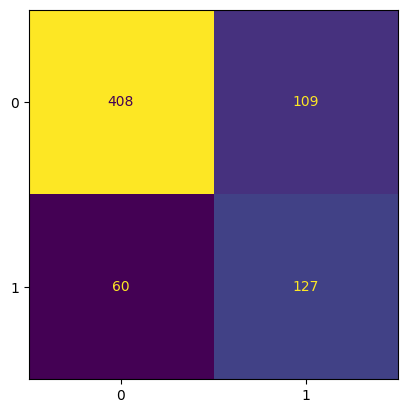

In [302]:
import matplotlib.pyplot as plt
from utils import estimate_quality

fig, axes = plt.subplots(1, 1)
estimate_quality(numpy.array(u), y_test, ax = axes)

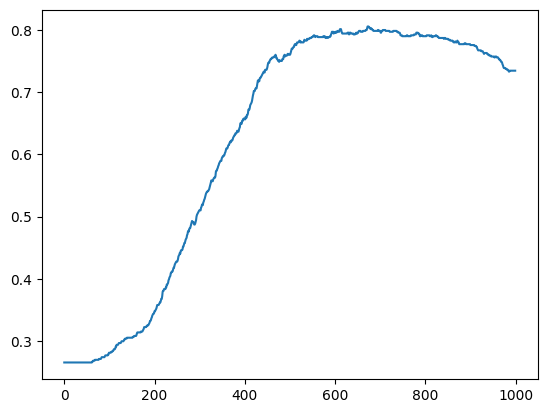

In [303]:
import sklearn.metrics

o = numpy.array(u)
acc = []
for threshold in range(0, 1000):
    thr = threshold / 1000.
    bn = o[:, 1] > thr
    acc.append(sklearn.metrics.accuracy_score(bn, y_test))

plt.plot(list(range(0, 1000)), acc)

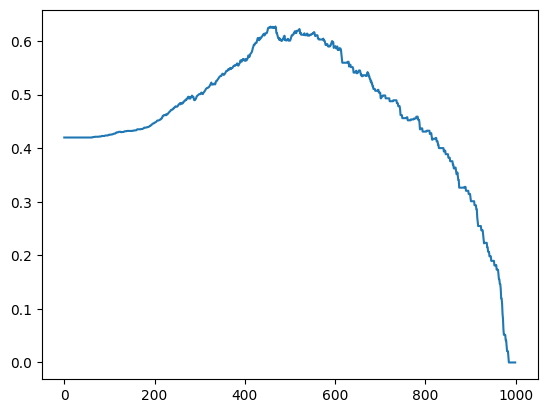

In [305]:
import sklearn.metrics

o = numpy.array(u)
acc = []
for threshold in range(0, 1000):
    thr = threshold / 1000.
    u = o[:, 1] > thr
    acc.append(sklearn.metrics.f1_score(u, y_test))

plt.plot(list(range(0, 1000)), acc)

In [306]:
print('F1: ', numpy.max(acc))

F1:  0.6269315673289183


In [ ]:
# Example: explanation for a single object
fca = LazyClassifierFCA()
fca.fit(X_train_df, y_train)
explanation = fca.explain_sample(X_test_df.iloc[0], top_k=5, verbose=True)
explanation


Positive:  {(False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, 1, 20, 20, 35, 85, 2917): 1, (False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, 1, 20, 20, 3, 35, 99): 1, (False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, 1, 20, 20, 6, 89, 573): 1, (False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, 1, 20, 20, 13, 89, 1132): 1, (True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, Fa

{'predicted_label': 0,
 'probabilities': {'negative': 0.5932158821982645,
  'positive': 0.40678411780173546},
 'num_positive_hypotheses': 1373,
 'num_negative_hypotheses': 2244,
 'top_positive_hypotheses': [{'weight': 11,
   'bool_conditions': ['InternetService No',
    'StreamingTV No internet service',
    'OnlineBackup No internet service',
    'DeviceProtection No internet service',
    'PaymentMethod Mailed check',
    'OnlineSecurity No internet service',
    'gender Male',
    'StreamingMovies No internet service',
    'TechSupport No internet service',
    'PhoneService Yes'],
   'numeric_conditions': ['tenure == 1',
    'MonthlyCharges == 20',
    'TotalCharges == 20']},
  {'weight': 11,
   'bool_conditions': ['InternetService No',
    'StreamingTV No internet service',
    'OnlineBackup No internet service',
    'DeviceProtection No internet service',
    'PaymentMethod Mailed check',
    'OnlineSecurity No internet service',
    'gender Male',
    'StreamingMovies No interne